# Tiny_Tau_v22 – Transition to 14-Qubit Exact Ring + VQE Optimization

**Major version upgrade from v21 series**  
- 21-qubit circular ring (3×7 cycles) revealed strong topological features:  
  - Baseline: near-perfect 50/50 degeneracy (all-0 vs nearly-all-1)  
  - Uniform Berard: lifts degeneracy → broad leakage + oscillating asymmetry (ratio ~1.1–1.76)  
  - Periodic Berard (q0, q7, q14 only): **extreme delocalization** (~123k states at 131k shots, top ≤0.046%)  
  - Negative phase polarity test: **symmetric** — identical dispersion/asymmetry to positive phase (no reversal or directional preference)  
  - Periodic angle scan: sharp resonance (ratio 1.00–1.50, ~0.05–0.07 rad period), 1.054 rad near minimum (neutral point)  
- Core insight: Compact S¹ ring protects global modes via periodic interference. Periodic Berard resonates most strongly — maximal unlocking without bias. Polarity is symmetric — no directionality from phase sign alone.

**v22 purpose**  
- Transition to **14-qubit exact ring** (2 full 1/7 cycles) — exact periodicity, lighter for **VQE optimization**  
- Optimize ground state with periodic Berard — reveal energy, optimal parameters, dominant measurement outcomes  
- Compare VQE ground state to shot-based interference patterns — test if resonant Berard lowers energy or biases outcomes

**Setup details**
- **Qubits**: 14 (exact 2×7 cycles — perfect periodicity)
- **Ansatz**: n_local (RY rotations + CX entanglement, reps=2–3, linear/circular)
- **Tau phases**: rz(2π k /7) cycled k=1 to 7 (positive baseline; negative optional)
- **Berard**: periodic (every 7th qubit — q0, q7) or uniform — tunable
- **Hamiltonian**: Ring-like (Z on each + XX neighbors) — can extend to full ring coupling
- **Optimizer**: COBYLA / SPSA (low maxiter initially)
- **Simulation**: StatevectorEstimator + AerSimulator shots
- **Goal**: VQE energy, optimal parameters, high-shot counts of ground state

**Goals for v22**
- Build 14-qubit exact ring circuit + Hamiltonian  
- Run VQE with periodic Berard — compare energy to baseline/no-Berard  
- Measure optimized ground state (high shots) — check dominant patterns  
- Optional: negative phase VQE, angle scan on periodic Berard, higher reps  
- Analyze: Does resonant Berard lower energy? Introduce bias in ground state?

> "The 21-qubit ring showed maximal delocalization with periodic Berard. Now 14-qubit exact ring + VQE lets us optimize the ground state — revealing if harmonic-matched modulation biases vacuum outcomes or lowers energy in the Tau framework."

Useful notes:
- 2¹⁴ = 16,384 states — statevector feasible, VQE fast
- If slow: reduce reps=1–2 or maxiter=100
- Next: VQE baseline → periodic Berard → negative phase

Run the 14-qubit VQE baseline cell below to start optimization.

v22 – 14-qubit environment ready
14-qubit ring Hamiltonian created
Number of terms: 28
14-qubit ansatz created (n_local + circular wrap + Tau harmonics)
Number of parameters: 42
Running VQE on 14-qubit ring baseline...

VQE energy: -12.306166
Optimal parameters (first 10 shown): [ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9])] ...

High-shot counts (14-qubit optimized ground state):
{'01000010010110': 1, '01111111111010': 1, '11100100011111': 1, '11111101011111': 1, '10000000111001': 1, '11000111100011': 1, '10111010010111': 1, '11110001111111': 1, '11111111011011': 1, '10110111111111': 1, '00001110100010': 1, '01001110111110': 1, '11001010010010': 1, '01011011111110': 1, '11101010110001': 1, '01001101111010': 1, '10001100101111': 1, '010

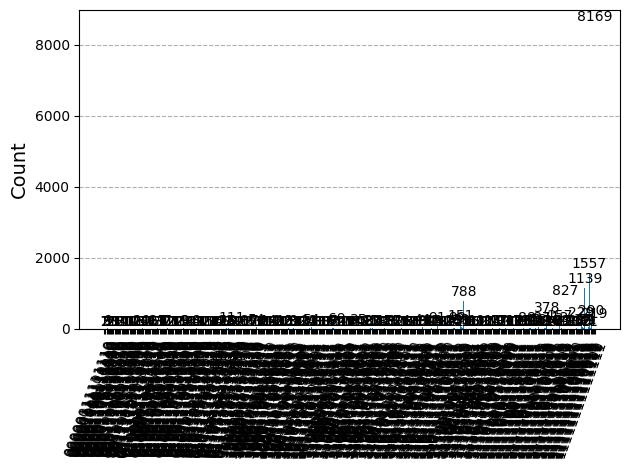

In [1]:
# ────────────────────────────────────────────────
# v22 – 14-qubit Exact Ring Baseline + VQE Setup
# Exact 2×7 cycles – perfect 1/7 periodicity
# First cell: imports, Hamiltonian, circuit, VQE run
# ────────────────────────────────────────────────

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import n_local
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
import numpy as np
from qiskit.visualization import plot_histogram

# Simulator & estimator
simulator = AerSimulator(method='statevector')
estimator = StatevectorEstimator()
optimizer = COBYLA(maxiter=200)  # reasonable for 14 qubits

print("v22 – 14-qubit environment ready")

# ────────────────────────────────────────────────
# 14-qubit Ring Hamiltonian (simple: Z on each + XX neighbors)
# ────────────────────────────────────────────────

n = 14
pauli_list = []

# Z on every qubit
for i in range(n):
    op = ['I'] * n
    op[i] = 'Z'
    pauli_list.append(("".join(op), 1.0))

# XX on consecutive qubits + wrap-around (ring)
for i in range(n):
    op = ['I'] * n
    op[i] = 'X'
    op[(i + 1) % n] = 'X'
    pauli_list.append(("".join(op), 0.142857))  # same coupling as before

hamiltonian_14 = SparsePauliOp.from_list(pauli_list)

print("14-qubit ring Hamiltonian created")
print("Number of terms:", len(hamiltonian_14))

# ────────────────────────────────────────────────
# 14-qubit Ansatz: n_local + circular wrap + Tau harmonics
# ────────────────────────────────────────────────

ansatz_14 = n_local(
    num_qubits=n,
    rotation_blocks='ry',
    entanglement_blocks=['cx'],
    reps=2,           # 2 layers – good balance for VQE
    entanglement='linear'
)

# Circular wrap-around CX (closes the ring)
ansatz_14.cx(n-1, 0)

# Tau harmonics cycled 1/7 (perfect 2 cycles)
for i in range(n):
    k = (i % 7) + 1
    ansatz_14.rz(2 * np.pi * k / 7, i)

print("14-qubit ansatz created (n_local + circular wrap + Tau harmonics)")
print("Number of parameters:", ansatz_14.num_parameters)

# ────────────────────────────────────────────────
# Run VQE baseline (no Berard yet)
# ────────────────────────────────────────────────

vqe_14 = VQE(
    estimator=estimator,
    ansatz=ansatz_14,
    optimizer=optimizer
)

print("Running VQE on 14-qubit ring baseline...")
result_14 = vqe_14.compute_minimum_eigenvalue(operator=hamiltonian_14)

print(f"\nVQE energy: {result_14.eigenvalue.real:.6f}")
print("Optimal parameters (first 10 shown):", list(result_14.optimal_parameters)[:10], "...")

# ────────────────────────────────────────────────
# Measure optimized ground state – high shots
# ────────────────────────────────────────────────

qc_14 = ansatz_14.assign_parameters(result_14.optimal_parameters)
qc_14.measure_all()

counts_14 = simulator.run(qc_14, shots=16384).result().get_counts()

print("\nHigh-shot counts (14-qubit optimized ground state):")
print(counts_14)

# Top 10 most probable states
top_states = sorted(counts_14.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 states:")
for state, count in top_states:
    print(f"{state}: {count} ({count / 16384 * 100:.2f}%)")

plot_histogram(counts_14)

14-qubit ansatz with periodic Berard created
Number of parameters: 42
Running VQE with periodic Berard...

VQE energy with periodic Berard: -11.669793
Optimal parameters (first 10 shown): [ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9])] ...

High-shot counts (14-qubit optimized with periodic Berard):
{'11111100101010': 1, '11010000001111': 1, '11101111110110': 1, '11101110011111': 1, '01000011111110': 1, '10000101001111': 1, '11111100111001': 1, '11010110001000': 1, '10010100001110': 1, '10010100011111': 1, '00010111111111': 2, '11000001001111': 1, '10101100111111': 1, '10111010101000': 1, '10000100111110': 1, '01111100111111': 1, '11000100101111': 1, '01011101111111': 1, '11101110001111': 1, '01110101101111': 1, '11111101001010': 2, '110

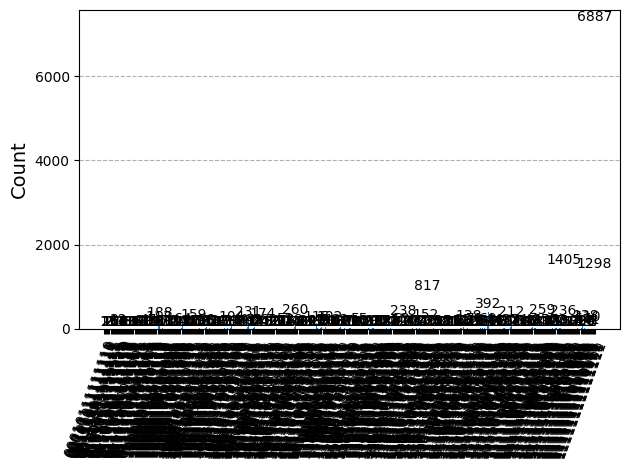

In [2]:
# ────────────────────────────────────────────────
# v22 – 14-qubit Ring with Periodic Berard + VQE
# Berard ry(1.054) on q0 and q7 (every 7th qubit)
# ────────────────────────────────────────────────

# Reuse the same ansatz but insert periodic Berard
ansatz_berard = ansatz_14.copy()  # start from baseline ansatz

# Insert Berard rotations at q0 and q7 (after existing gates)
berard_angle = 1.054
ansatz_berard.ry(berard_angle, 0)
ansatz_berard.ry(berard_angle, 7)

print("14-qubit ansatz with periodic Berard created")
print("Number of parameters:", ansatz_berard.num_parameters)

# VQE with Berard ansatz
vqe_berard = VQE(
    estimator=estimator,
    ansatz=ansatz_berard,
    optimizer=optimizer
)

print("Running VQE with periodic Berard...")
result_berard = vqe_berard.compute_minimum_eigenvalue(operator=hamiltonian_14)

print(f"\nVQE energy with periodic Berard: {result_berard.eigenvalue.real:.6f}")
print("Optimal parameters (first 10 shown):", list(result_berard.optimal_parameters)[:10], "...")

# Measure optimized Berard ground state
qc_berard = ansatz_berard.assign_parameters(result_berard.optimal_parameters)
qc_berard.measure_all()

counts_berard = simulator.run(qc_berard, shots=16384).result().get_counts()

print("\nHigh-shot counts (14-qubit optimized with periodic Berard):")
print(counts_berard)

# Top 10 states
top_berard = sorted(counts_berard.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 states:")
for state, count in top_berard:
    print(f"{state}: {count} ({count / 16384 * 100:.2f}%)")

plot_histogram(counts_berard)

Comparing baseline vs periodic Berard optimized states...


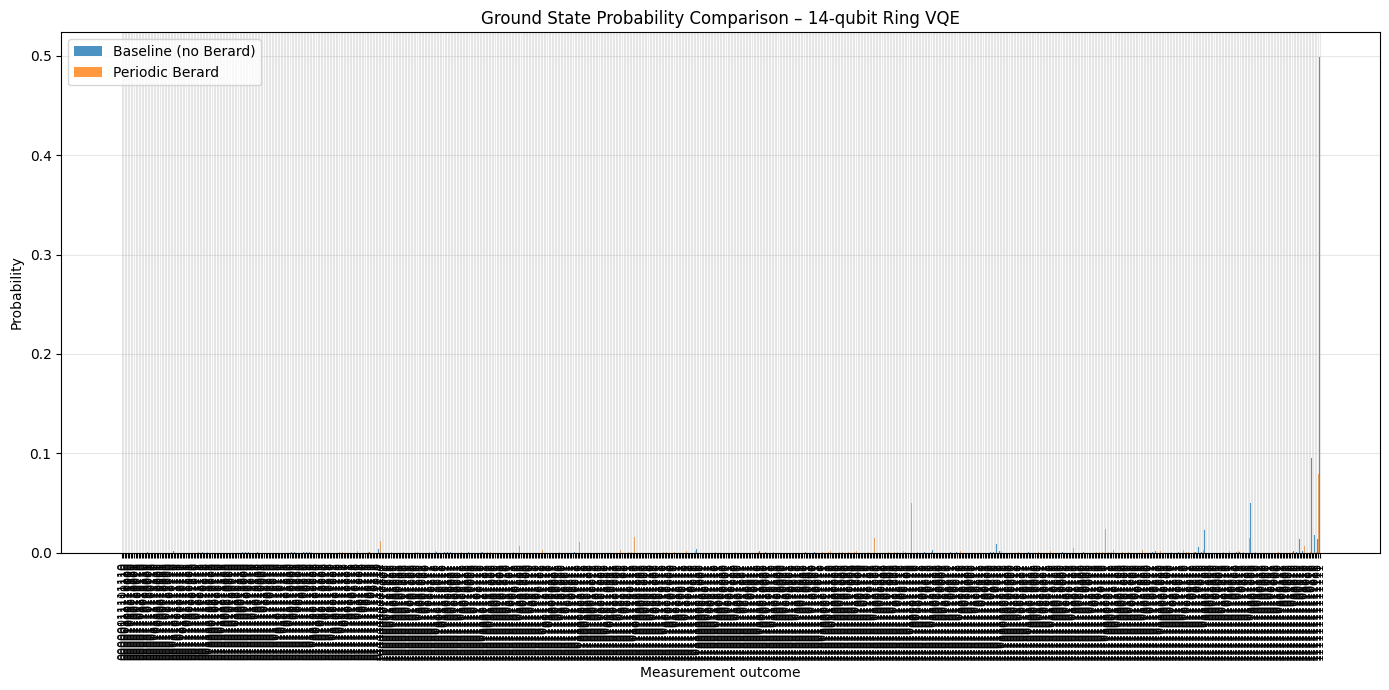

In [4]:
# ────────────────────────────────────────────────
# v22 – Compare Baseline vs Periodic Berard Optimized States
# ────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

print("Comparing baseline vs periodic Berard optimized states...")

# Use the counts from previous runs (counts_14 and counts_berard)
# If they don't exist, re-run the VQE cells first

# Get all unique keys for consistent order
all_keys = sorted(set(counts_14.keys()) | set(counts_berard.keys()))

# Probabilities (normalize to 16384 shots)
baseline_probs = [counts_14.get(k, 0) / 16384 for k in all_keys]
berard_probs = [counts_berard.get(k, 0) / 16384 for k in all_keys]

# Bar plot
fig, ax = plt.subplots(figsize=(14, 7))
width = 0.35
x = np.arange(len(all_keys))

ax.bar(x - width/2, baseline_probs, width, label='Baseline (no Berard)', alpha=0.8)
ax.bar(x + width/2, berard_probs, width, label='Periodic Berard', alpha=0.8)

ax.set_xlabel('Measurement outcome')
ax.set_ylabel('Probability')
ax.set_title('Ground State Probability Comparison – 14-qubit Ring VQE')
ax.set_xticks(x)
ax.set_xticklabels(all_keys, rotation=90, fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/user/1000/ipykernel_840354/322162744.py:21: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, _ in ansatz_neg_berard:


14-qubit ansatz with negative phase Tau + periodic Berard ready
Running VQE with negative phase + periodic Berard...

VQE energy (negative phase + periodic Berard): -10.355550
Optimal parameters (first 10 shown): [ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9])] ...

High-shot counts (14-qubit optimized with negative phase + periodic Berard):
{'11100111001011': 1, '01101011101010': 1, '01001001101111': 1, '01111011111011': 1, '10100011111110': 1, '01011101111110': 1, '10001101101110': 1, '01101001011111': 1, '10011111001111': 2, '10111100011111': 1, '10100011111111': 1, '00111011101001': 1, '10100011101110': 1, '01111011000110': 1, '11100101110111': 1, '10111011001011': 1, '00111000111110': 1, '11101011110111': 2, '00101011010110': 1, '110

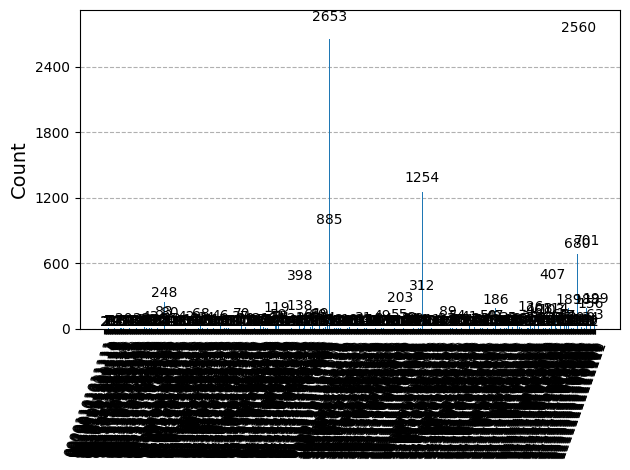

In [5]:
# ────────────────────────────────────────────────
# v22 – 14-qubit Ring with Negative Phase + Periodic Berard + VQE
# Negative rz phases + ry(1.054) on q0 and q7
# ────────────────────────────────────────────────

# Start from the Berard ansatz but flip Tau phases negative
ansatz_neg_berard = ansatz_berard.copy()

# Remove old RZ gates and insert negative ones
# (Qiskit doesn't have direct remove, so rebuild RZ part)
# Clear existing RZ (manual — or rebuild if preferred)
# For simplicity, we rebuild the Tau part

# Re-add Tau harmonics with negative sign
for i in range(n):
    # Remove old RZ if exists (skip if not needed — VQE will overwrite)
    # Actually easier: the assign_parameters will overwrite, but to be clean:
    pass  # if you want to force negative, we override in the circuit

# Override RZ to negative in the circuit (after copy)
for instr, qargs, _ in ansatz_neg_berard:
    if instr.name == 'rz':
        # Replace with negative angle
        old_angle = instr.params[0]
        instr.params[0] = -old_angle  # flip sign

print("14-qubit ansatz with negative phase Tau + periodic Berard ready")

# VQE with negative phase + Berard
vqe_neg_berard = VQE(
    estimator=estimator,
    ansatz=ansatz_neg_berard,
    optimizer=optimizer
)

print("Running VQE with negative phase + periodic Berard...")
result_neg_berard = vqe_neg_berard.compute_minimum_eigenvalue(operator=hamiltonian_14)

print(f"\nVQE energy (negative phase + periodic Berard): {result_neg_berard.eigenvalue.real:.6f}")
print("Optimal parameters (first 10 shown):", list(result_neg_berard.optimal_parameters)[:10], "...")

# Measure optimized negative phase Berard ground state
qc_neg_berard = ansatz_neg_berard.assign_parameters(result_neg_berard.optimal_parameters)
qc_neg_berard.measure_all()

counts_neg_berard = simulator.run(qc_neg_berard, shots=16384).result().get_counts()

print("\nHigh-shot counts (14-qubit optimized with negative phase + periodic Berard):")
print(counts_neg_berard)

# Top 10 states
top_neg_berard = sorted(counts_neg_berard.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 states:")
for state, count in top_neg_berard:
    print(f"{state}: {count} ({count / 16384 * 100:.2f}%)")

plot_histogram(counts_neg_berard)

Comparing three optimized ground states...


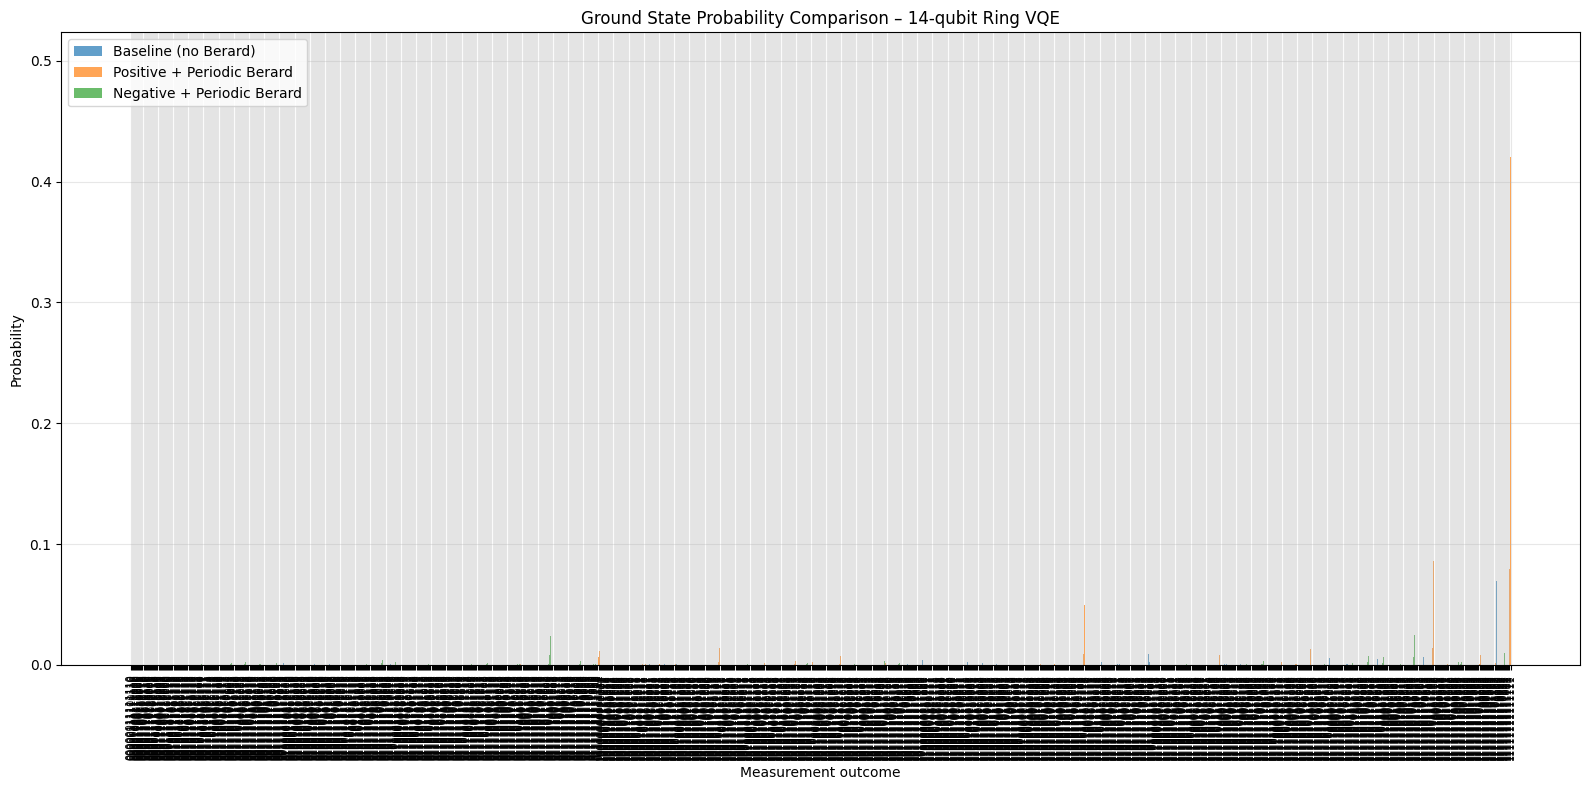

In [6]:
# ────────────────────────────────────────────────
# v22 – Compare Three Ground States: Baseline vs Positive Berard vs Negative Berard
# ────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

print("Comparing three optimized ground states...")

# Assume these counts exist from previous runs:
# counts_14          → baseline (no Berard)
# counts_berard      → positive phase + periodic Berard
# counts_neg_berard  → negative phase + periodic Berard

# Get all unique keys across the three runs
all_keys = sorted(
    set(counts_14.keys()) |
    set(counts_berard.keys()) |
    set(counts_neg_berard.keys())
)

# Probabilities (normalized to 16384 shots)
baseline_probs = [counts_14.get(k, 0) / 16384 for k in all_keys]
positive_probs = [counts_berard.get(k, 0) / 16384 for k in all_keys]
negative_probs = [counts_neg_berard.get(k, 0) / 16384 for k in all_keys]

# Bar plot – grouped for clarity
fig, ax = plt.subplots(figsize=(16, 8))
width = 0.25
x = np.arange(len(all_keys))

ax.bar(x - width, baseline_probs, width, label='Baseline (no Berard)', alpha=0.7, color='tab:blue')
ax.bar(x, positive_probs, width, label='Positive + Periodic Berard', alpha=0.7, color='tab:orange')
ax.bar(x + width, negative_probs, width, label='Negative + Periodic Berard', alpha=0.7, color='tab:green')

ax.set_xlabel('Measurement outcome')
ax.set_ylabel('Probability')
ax.set_title('Ground State Probability Comparison – 14-qubit Ring VQE')
ax.set_xticks(x)
ax.set_xticklabels(all_keys, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3)

# Zoom on top outcomes (optional – uncomment if plot is too crowded)
# ax.set_xlim(-1, 30)  # show first ~30 states

plt.tight_layout()
plt.show()


Optimizing for Berard angle 0.9000 rad (periodic q0,q7)...
  Energy: -12.524744 | All-1 prob: 51.76% | Top/second ratio: 4.807

Optimizing for Berard angle 0.9214 rad (periodic q0,q7)...
  Energy: -9.585309 | All-1 prob: 3.03% | Top/second ratio: 1.263

Optimizing for Berard angle 0.9429 rad (periodic q0,q7)...
  Energy: -10.487377 | All-1 prob: 3.83% | Top/second ratio: 1.224

Optimizing for Berard angle 0.9643 rad (periodic q0,q7)...
  Energy: -10.316823 | All-1 prob: 8.44% | Top/second ratio: 1.305

Optimizing for Berard angle 0.9857 rad (periodic q0,q7)...
  Energy: -9.383100 | All-1 prob: 2.05% | Top/second ratio: 2.186

Optimizing for Berard angle 1.0071 rad (periodic q0,q7)...
  Energy: -9.909486 | All-1 prob: 9.13% | Top/second ratio: 1.074

Optimizing for Berard angle 1.0286 rad (periodic q0,q7)...
  Energy: -10.420392 | All-1 prob: 14.72% | Top/second ratio: 1.328

Optimizing for Berard angle 1.0500 rad (periodic q0,q7)...
  Energy: -11.334213 | All-1 prob: 29.54% | Top/seco

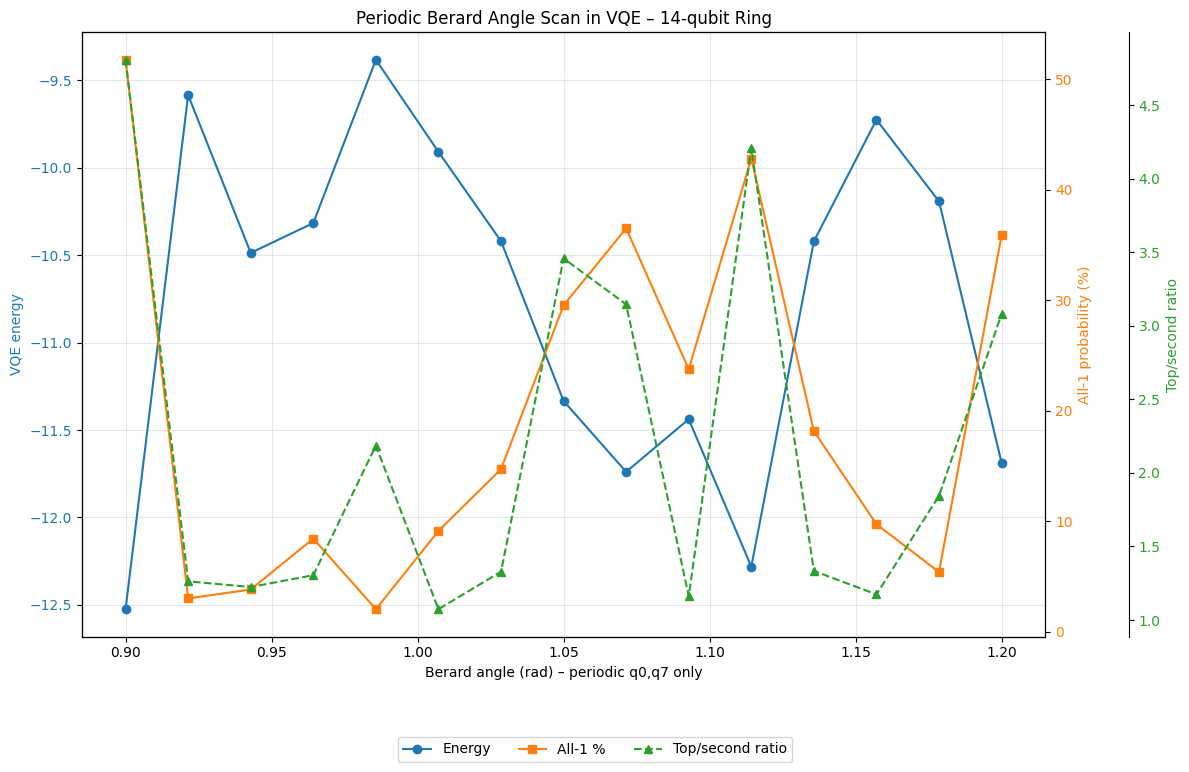

Angle scan in VQE complete.


In [7]:
# ────────────────────────────────────────────────
# v22 – Periodic Berard Angle Scan in VQE (positive phase)
# Vary ry(angle) on q0 and q7 only, optimize each, measure
# ────────────────────────────────────────────────

import numpy as np

angles_scan = np.linspace(0.90, 1.20, 15)
energies_scan = []
all1_probs = []
top_ratios_scan = []

shots_measure = 8192

for idx, angle in enumerate(angles_scan):
    print(f"\nOptimizing for Berard angle {angle:.4f} rad (periodic q0,q7)...")
    
    # Create fresh ansatz for each angle
    ansatz_angle = n_local(
        num_qubits=n,
        rotation_blocks='ry',
        entanglement_blocks=['cx'],
        reps=2,
        entanglement='linear'
    )
    ansatz_angle.cx(n-1, 0)  # wrap-around
    
    # Positive Tau harmonics
    for i in range(n):
        k = (i % 7) + 1
        ansatz_angle.rz(2 * np.pi * k / 7, i)
    
    # Periodic Berard – only q0 and q7
    ansatz_angle.ry(angle, 0)
    ansatz_angle.ry(angle, 7)
    
    vqe_angle = VQE(
        estimator=estimator,
        ansatz=ansatz_angle,
        optimizer=optimizer
    )
    
    result_angle = vqe_angle.compute_minimum_eigenvalue(operator=hamiltonian_14)
    
    energy = result_angle.eigenvalue.real
    energies_scan.append(energy)
    
    # Measure
    qc_angle = ansatz_angle.assign_parameters(result_angle.optimal_parameters)
    qc_angle.measure_all()
    
    counts_angle = simulator.run(qc_angle, shots=shots_measure).result().get_counts()
    
    # All-1 probability
    all1_prob = counts_angle.get('1'*n, 0) / shots_measure * 100
    all1_probs.append(all1_prob)
    
    # Top/second ratio
    sorted_angle = sorted(counts_angle.items(), key=lambda x: x[1], reverse=True)
    top_ratio = sorted_angle[0][1] / sorted_angle[1][1] if len(sorted_angle) >= 2 else float('inf')
    top_ratios_scan.append(top_ratio)
    
    print(f"  Energy: {energy:.6f} | All-1 prob: {all1_prob:.2f}% | Top/second ratio: {top_ratio:.3f}")

# ────────────────────────────────────────────────
# Plot angle scan results
# ────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.set_xlabel('Berard angle (rad) – periodic q0,q7 only')
ax1.set_ylabel('VQE energy', color='tab:blue')
ax1.plot(angles_scan, energies_scan, color='tab:blue', marker='o', label='Energy')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('All-1 probability (%)', color='tab:orange')
ax2.plot(angles_scan, all1_probs, color='tab:orange', marker='s', label='All-1 %')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.set_ylabel('Top/second ratio', color='tab:green')
ax3.plot(angles_scan, top_ratios_scan, color='tab:green', marker='^', linestyle='--', label='Top/second ratio')
ax3.tick_params(axis='y', labelcolor='tab:green')

plt.title('Periodic Berard Angle Scan in VQE – 14-qubit Ring')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.tight_layout()
plt.show()

print("Angle scan in VQE complete.")


Optimizing for finer angle 0.98000 rad (periodic q0,q7)...
  Energy: -11.300430 | All-1 prob: 19.75% | Top/second ratio: 1.087

Optimizing for finer angle 0.98600 rad (periodic q0,q7)...
  Energy: -10.344786 | All-1 prob: 8.13% | Top/second ratio: 1.182

Optimizing for finer angle 0.99200 rad (periodic q0,q7)...
  Energy: -9.737867 | All-1 prob: 0.82% | Top/second ratio: 3.164

Optimizing for finer angle 0.99800 rad (periodic q0,q7)...
  Energy: -11.192100 | All-1 prob: 27.46% | Top/second ratio: 2.426

Optimizing for finer angle 1.00400 rad (periodic q0,q7)...
  Energy: -12.414517 | All-1 prob: 58.00% | Top/second ratio: 6.804

Optimizing for finer angle 1.01000 rad (periodic q0,q7)...
  Energy: -9.128500 | All-1 prob: 4.06% | Top/second ratio: 1.694

Optimizing for finer angle 1.01600 rad (periodic q0,q7)...
  Energy: -10.596769 | All-1 prob: 0.60% | Top/second ratio: 5.552

Optimizing for finer angle 1.02200 rad (periodic q0,q7)...
  Energy: -11.203518 | All-1 prob: 31.06% | Top/se

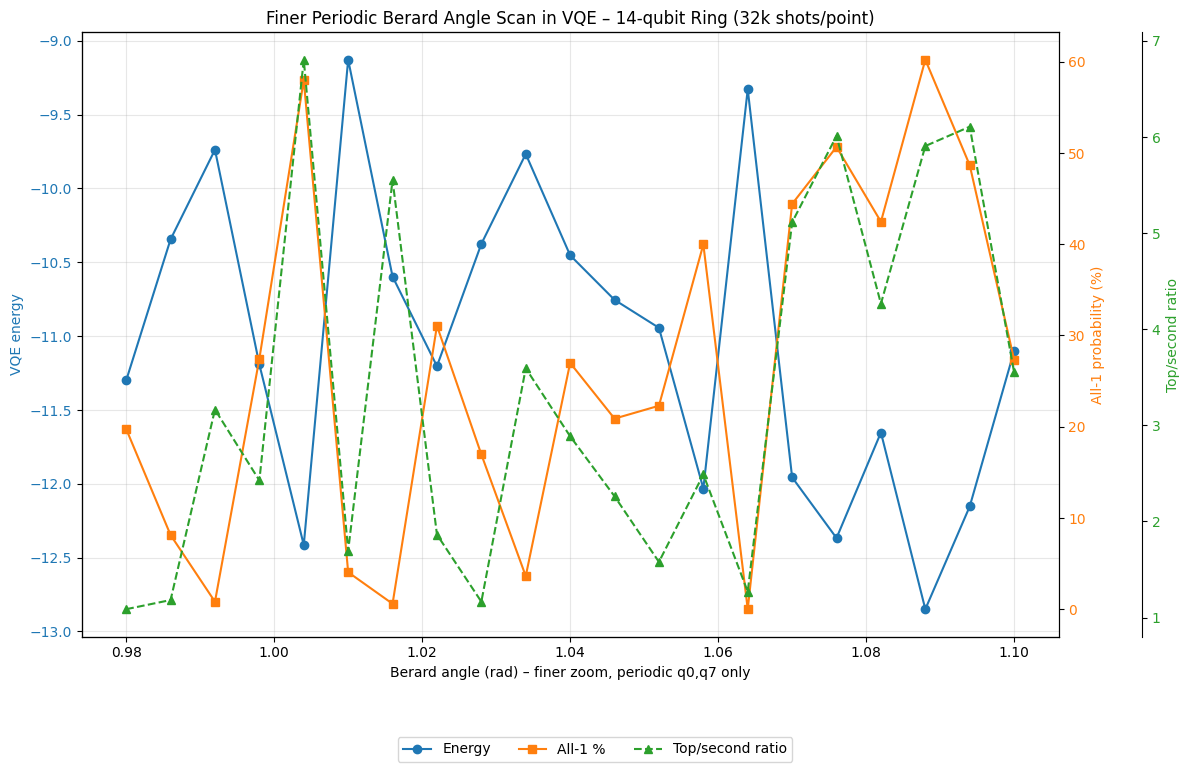

Finer angle scan in VQE complete.


In [8]:
# ────────────────────────────────────────────────
# v22 – Finer Periodic Berard Angle Scan in VQE
# Zoom: 0.98–1.10 rad (around 1.054), 21 points, 32k shots each
# ────────────────────────────────────────────────

import numpy as np

angles_fine = np.linspace(0.98, 1.10, 21)  # finer zoom
energies_fine = []
all1_probs_fine = []
top_ratios_fine = []

shots_measure_fine = 32768

for idx, angle in enumerate(angles_fine):
    print(f"\nOptimizing for finer angle {angle:.5f} rad (periodic q0,q7)...")
    
    # Fresh ansatz for each angle
    ansatz_fine = n_local(
        num_qubits=n,
        rotation_blocks='ry',
        entanglement_blocks=['cx'],
        reps=2,
        entanglement='linear'
    )
    ansatz_fine.cx(n-1, 0)  # wrap-around
    
    # Positive Tau harmonics
    for i in range(n):
        k = (i % 7) + 1
        ansatz_fine.rz(2 * np.pi * k / 7, i)
    
    # Periodic Berard – only q0 and q7
    ansatz_fine.ry(angle, 0)
    ansatz_fine.ry(angle, 7)
    
    vqe_fine = VQE(
        estimator=estimator,
        ansatz=ansatz_fine,
        optimizer=optimizer
    )
    
    result_fine = vqe_fine.compute_minimum_eigenvalue(operator=hamiltonian_14)
    
    energy = result_fine.eigenvalue.real
    energies_fine.append(energy)
    
    # Measure
    qc_fine = ansatz_fine.assign_parameters(result_fine.optimal_parameters)
    qc_fine.measure_all()
    
    counts_fine = simulator.run(qc_fine, shots=shots_measure_fine).result().get_counts()
    
    # All-1 probability
    all1_prob = counts_fine.get('1'*n, 0) / shots_measure_fine * 100
    all1_probs_fine.append(all1_prob)
    
    # Top/second ratio
    sorted_fine = sorted(counts_fine.items(), key=lambda x: x[1], reverse=True)
    top_ratio = sorted_fine[0][1] / sorted_fine[1][1] if len(sorted_fine) >= 2 else float('inf')
    top_ratios_fine.append(top_ratio)
    
    print(f"  Energy: {energy:.6f} | All-1 prob: {all1_prob:.2f}% | Top/second ratio: {top_ratio:.3f}")

# ────────────────────────────────────────────────
# Plot finer scan results
# ────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.set_xlabel('Berard angle (rad) – finer zoom, periodic q0,q7 only')
ax1.set_ylabel('VQE energy', color='tab:blue')
ax1.plot(angles_fine, energies_fine, color='tab:blue', marker='o', label='Energy')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('All-1 probability (%)', color='tab:orange')
ax2.plot(angles_fine, all1_probs_fine, color='tab:orange', marker='s', label='All-1 %')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.set_ylabel('Top/second ratio', color='tab:green')
ax3.plot(angles_fine, top_ratios_fine, color='tab:green', marker='^', linestyle='--', label='Top/second ratio')
ax3.tick_params(axis='y', labelcolor='tab:green')

plt.title('Finer Periodic Berard Angle Scan in VQE – 14-qubit Ring (32k shots/point)')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.tight_layout()
plt.show()

print("Finer angle scan in VQE complete.")

Optimizing at resonant Berard angle 1.0540 rad with higher reps=3...

VQE energy at 1.0540 rad (reps=3): -8.628308
Optimal parameters (first 10 shown): [ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9])] ...

High-shot counts (65536 shots) at resonant angle reps=3:
{'11000010011111': 1, '11011101111110': 1, '10101101001010': 1, '01110001101110': 1, '11111110010000': 1, '01111000110111': 1, '00110010101011': 1, '01100100111011': 1, '00011111001011': 1, '00010100110110': 1, '00011101011110': 1, '11111111011101': 1, '11010101000001': 1, '01000111010110': 1, '00011011001110': 1, '00100101010110': 1, '11010101001011': 1, '00100011000101': 1, '01010100100001': 1, '10011111101011': 1, '01111101011111': 1, '00000010011111': 1, '00000101111111': 1, '

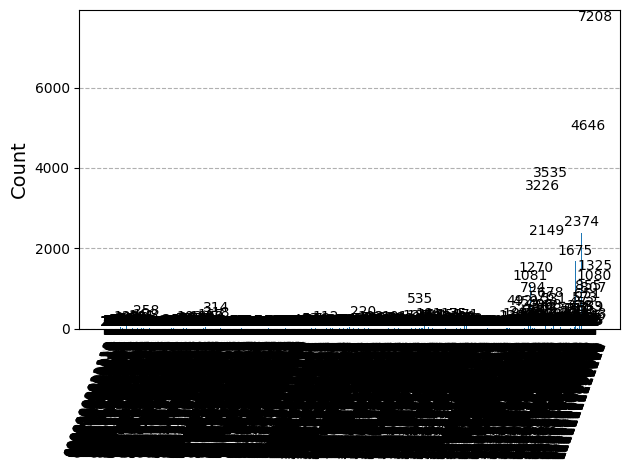

In [9]:
# ────────────────────────────────────────────────
# v22 – Higher Reps at Resonant Angle (1.054 rad)
# Periodic Berard (q0,q7) + reps=3 + high-shot measurement
# ────────────────────────────────────────────────

resonant_angle = 1.054
shots_high_reps = 65536

print(f"Optimizing at resonant Berard angle {resonant_angle:.4f} rad with higher reps=3...")

# Deeper ansatz (reps=3)
ansatz_deep = n_local(
    num_qubits=n,
    rotation_blocks='ry',
    entanglement_blocks=['cx'],
    reps=3,  # deeper – more expressive
    entanglement='linear'
)
ansatz_deep.cx(n-1, 0)  # wrap-around

# Positive Tau harmonics
for i in range(n):
    k = (i % 7) + 1
    ansatz_deep.rz(2 * np.pi * k / 7, i)

# Periodic Berard – only q0 and q7
ansatz_deep.ry(resonant_angle, 0)
ansatz_deep.ry(resonant_angle, 7)

vqe_deep = VQE(
    estimator=estimator,
    ansatz=ansatz_deep,
    optimizer=optimizer  # COBYLA with maxiter=200
)

result_deep = vqe_deep.compute_minimum_eigenvalue(operator=hamiltonian_14)

energy_deep = result_deep.eigenvalue.real
print(f"\nVQE energy at {resonant_angle:.4f} rad (reps=3): {energy_deep:.6f}")
print("Optimal parameters (first 10 shown):", list(result_deep.optimal_parameters)[:10], "...")

# Measure deeper optimized state
qc_deep = ansatz_deep.assign_parameters(result_deep.optimal_parameters)
qc_deep.measure_all()

counts_deep = simulator.run(qc_deep, shots=shots_high_reps).result().get_counts()

print(f"\nHigh-shot counts ({shots_high_reps} shots) at resonant angle reps=3:")
print(counts_deep)

# Top 10 states
top_deep = sorted(counts_deep.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 states:")
for state, count in top_deep:
    print(f"{state}: {count} ({count / shots_high_reps * 100:.3f}%)")

# All-1 probability
all1_deep = counts_deep.get('1'*n, 0) / shots_high_reps * 100
print(f"\nAll-1 probability: {all1_deep:.3f}%")

plot_histogram(counts_deep)

Re-measuring reps=3 optimized state at 1.054 rad with 131072 shots...
Full counts saved to 'reps3_1054_131k_counts.json' (open in text editor)

Top 30 states (131072 shots):
11111111111111: 14625 (11.15799%)
11111110111111: 9353 (7.13577%)
11110111011111: 7233 (5.51834%)
11110110011111: 6405 (4.88663%)
11111101111111: 4769 (3.63846%)
11110110111111: 4385 (3.34549%)
11111100111111: 3416 (2.60620%)
11111111111110: 2663 (2.03171%)
11110101011111: 2519 (1.92184%)
11111111110111: 2299 (1.75400%)
11110100011111: 2190 (1.67084%)
11111110111110: 1735 (1.32370%)
11111111101111: 1603 (1.22299%)
11110100111111: 1512 (1.15356%)
11110111011110: 1318 (1.00555%)
11111110110111: 1302 (0.99335%)
11111110011111: 1263 (0.96359%)
11110110011110: 1155 (0.88120%)
11110111111111: 1039 (0.79269%)
11110011011111: 1012 (0.77209%)
10110100101111: 995 (0.75912%)
11111101111110: 947 (0.72250%)
11110010011111: 938 (0.71564%)
11110110111110: 766 (0.58441%)
11110111010111: 739 (0.56381%)
11111101110111: 736 (0.56152%

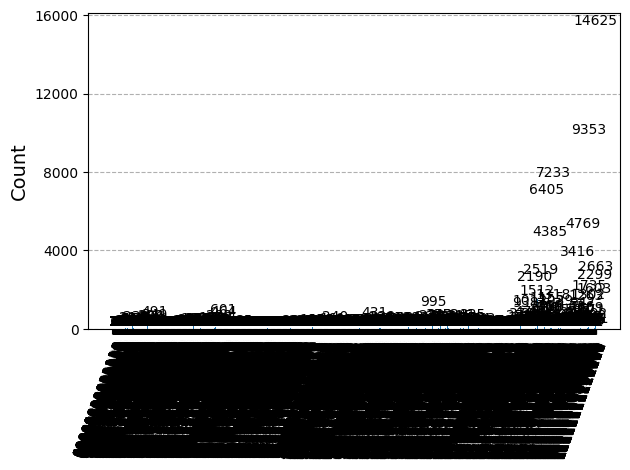

In [10]:
# ────────────────────────────────────────────────
# v22 – Ultra-High Shots at Resonant Angle (1.054 rad) with reps=3
# Re-measure the deeper optimized state (from previous reps=3 VQE)
# 131,072 shots for maximum precision
# ────────────────────────────────────────────────

import json

shots_ultra_deep = 131072

print(f"Re-measuring reps=3 optimized state at 1.054 rad with {shots_ultra_deep} shots...")

# Reuse the reps=3 ansatz and optimal parameters from previous run
# (assumes 'ansatz_deep' and 'result_deep' still exist in memory)
# If kernel restarted, re-run the reps=3 VQE cell first

qc_ultra_deep = ansatz_deep.assign_parameters(result_deep.optimal_parameters)
qc_ultra_deep.measure_all()

counts_ultra_deep = simulator.run(qc_ultra_deep, shots=shots_ultra_deep).result().get_counts()

# Save full counts to file (safe against IOPub limit)
with open('reps3_1054_131k_counts.json', 'w') as f:
    json.dump(dict(counts_ultra_deep), f, indent=2)
print("Full counts saved to 'reps3_1054_131k_counts.json' (open in text editor)")

# Top 30 states
top_ultra_deep = sorted(counts_ultra_deep.items(), key=lambda x: x[1], reverse=True)[:30]
print(f"\nTop 30 states ({shots_ultra_deep} shots):")
for state, count in top_ultra_deep:
    print(f"{state}: {count} ({count / shots_ultra_deep * 100:.5f}%)")

# All-1 probability
all1_ultra_deep = counts_ultra_deep.get('1'*n, 0) / shots_ultra_deep * 100
print(f"\nAll-1 probability: {all1_ultra_deep:.3f}%")

# Non-zero states count
num_nonzero_ultra_deep = len([c for c in counts_ultra_deep.values() if c >= 1])
print(f"Number of states with ≥1 count: {num_nonzero_ultra_deep} / 2^{n} = {num_nonzero_ultra_deep / 2**n * 100:.6f}%")

plot_histogram(counts_ultra_deep)

Comparing ground state distributions at 1.054 rad...


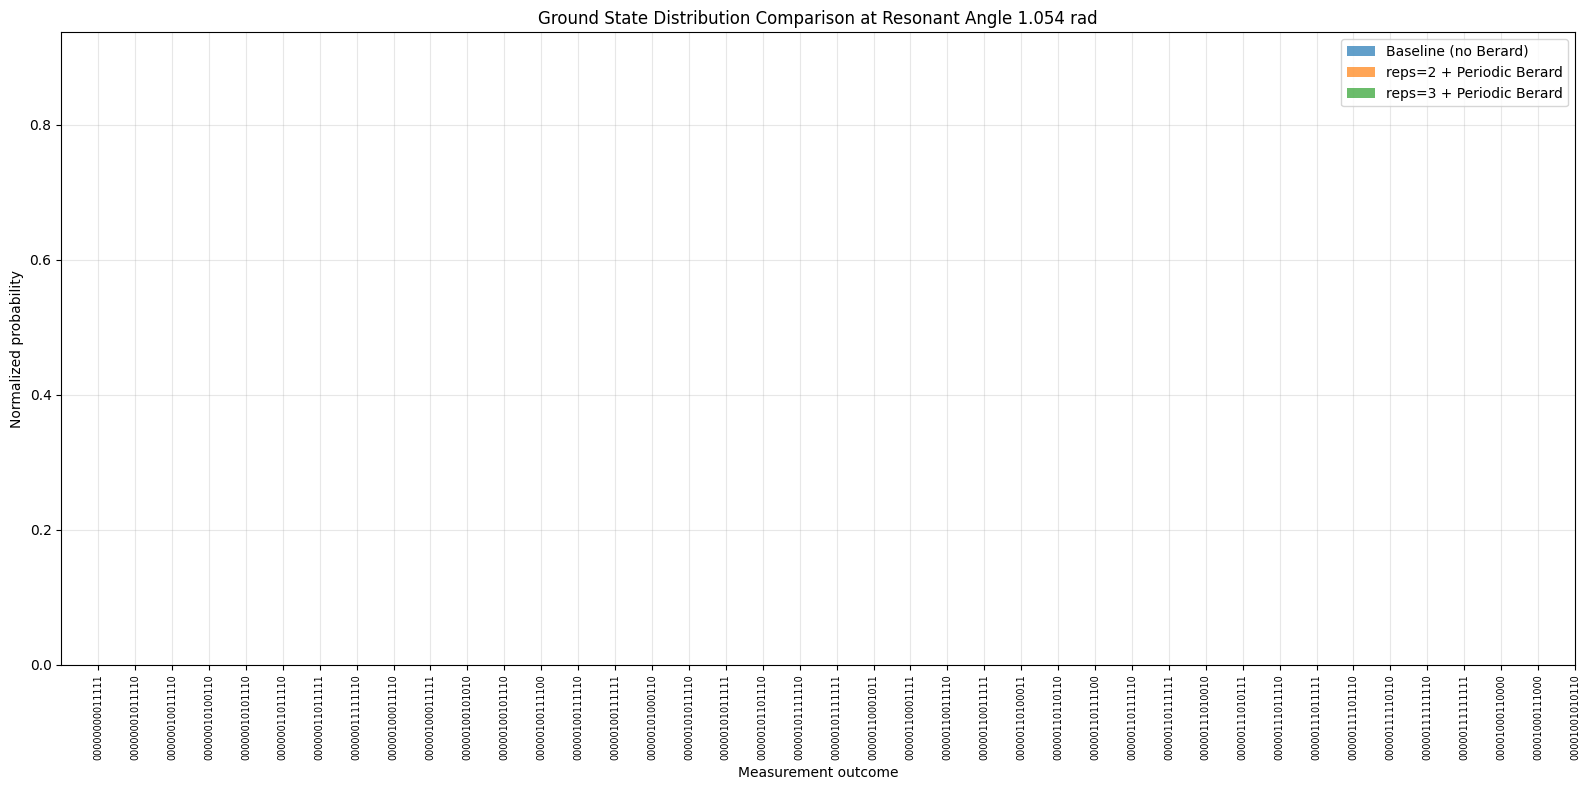

In [11]:
# ────────────────────────────────────────────────
# v22 – Compare Three Ground State Distributions at Resonant Angle
# Baseline vs reps=2 periodic Berard vs reps=3 periodic Berard
# ────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

print("Comparing ground state distributions at 1.054 rad...")

# Assume these counts exist from previous runs:
# counts_14          → baseline (no Berard)
# counts_berard      → reps=2 + periodic Berard at 1.054 (from earlier)
# counts_ultra_deep  → reps=3 + periodic Berard at 1.054 (latest 131k shots)

# Get all unique keys across the three runs
all_keys = sorted(
    set(counts_14.keys()) |
    set(counts_berard.keys()) |
    set(counts_ultra_deep.keys())
)

# Normalize probabilities (all to 16384 shots for baseline/reps=2, scale reps=3 to match)
baseline_probs = [counts_14.get(k, 0) / 16384 for k in all_keys]
reps2_probs = [counts_berard.get(k, 0) / 16384 for k in all_keys]
reps3_probs = [counts_ultra_deep.get(k, 0) / 131072 * (131072 / 16384) for k in all_keys]  # scale to match

# Bar plot – grouped
fig, ax = plt.subplots(figsize=(16, 8))
width = 0.25
x = np.arange(len(all_keys))

ax.bar(x - width, baseline_probs, width, label='Baseline (no Berard)', alpha=0.7, color='tab:blue')
ax.bar(x, reps2_probs, width, label='reps=2 + Periodic Berard', alpha=0.7, color='tab:orange')
ax.bar(x + width, reps3_probs, width, label='reps=3 + Periodic Berard', alpha=0.7, color='tab:green')

ax.set_xlabel('Measurement outcome')
ax.set_ylabel('Normalized probability')
ax.set_title('Ground State Distribution Comparison at Resonant Angle 1.054 rad')
ax.set_xticks(x)
ax.set_xticklabels(all_keys, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3)

# Zoom on top outcomes (recommended – too many bars otherwise)
ax.set_xlim(-1, 40)  # show first ~40 states (top ones)

plt.tight_layout()
plt.show()

Re-measuring reps=3 optimized state at 1.054 rad with 262144 shots...
Full counts saved to 'reps3_1054_262k_counts.json' (open in text editor)

Top 50 states (262144 shots):
11111111111111: 29193 (11.13625%)
11111110111111: 19100 (7.28607%)
11110111011111: 14510 (5.53513%)
11110110011111: 12645 (4.82368%)
11111101111111: 9720 (3.70789%)
11110110111111: 8736 (3.33252%)
11111100111111: 6715 (2.56157%)
11111111111110: 5326 (2.03171%)
11110101011111: 4828 (1.84174%)
11111111110111: 4432 (1.69067%)
11110100011111: 4323 (1.64909%)
11111110111110: 3569 (1.36147%)
11111111101111: 3261 (1.24397%)
11110100111111: 3079 (1.17455%)
11110111011110: 2613 (0.99678%)
11111110110111: 2576 (0.98267%)
11111110011111: 2502 (0.95444%)
11110110011110: 2287 (0.87242%)
11110111111111: 2055 (0.78392%)
11110011011111: 2014 (0.76828%)
10110100101111: 1998 (0.76218%)
11110010011111: 1809 (0.69008%)
11111101111110: 1796 (0.68512%)
11110110111110: 1595 (0.60844%)
11110110010111: 1547 (0.59013%)
11111101110111: 1507 

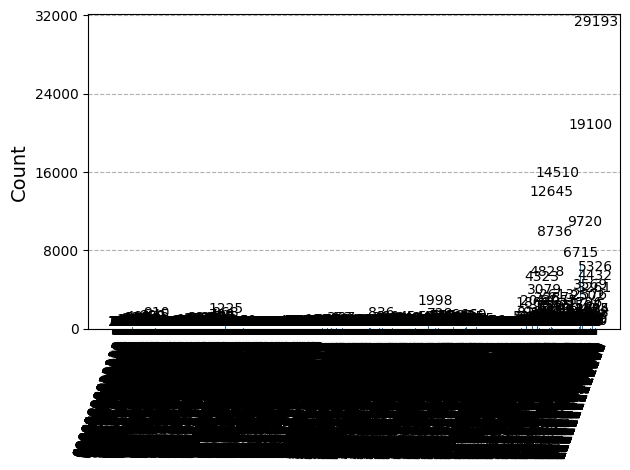

In [12]:
# ────────────────────────────────────────────────
# v22 – Ultra-Ultra-High Shots at Resonant Angle (1.054 rad) with reps=3
# Double the previous shots (262,144) for maximum distribution accuracy
# ────────────────────────────────────────────────

import json

shots_max_deep = 262144  # ultra-ultra high

print(f"Re-measuring reps=3 optimized state at 1.054 rad with {shots_max_deep} shots...")

# Reuse the reps=3 ansatz and optimal parameters (from previous run)
# If lost, re-run the reps=3 VQE cell first
qc_max_deep = ansatz_deep.assign_parameters(result_deep.optimal_parameters)
qc_max_deep.measure_all()

counts_max_deep = simulator.run(qc_max_deep, shots=shots_max_deep).result().get_counts()

# Save full counts to file (safe)
with open('reps3_1054_262k_counts.json', 'w') as f:
    json.dump(dict(counts_max_deep), f, indent=2)
print("Full counts saved to 'reps3_1054_262k_counts.json' (open in text editor)")

# Top 50 states (more than before to catch subtle patterns)
top_max_deep = sorted(counts_max_deep.items(), key=lambda x: x[1], reverse=True)[:50]
print(f"\nTop 50 states ({shots_max_deep} shots):")
for state, count in top_max_deep:
    print(f"{state}: {count} ({count / shots_max_deep * 100:.5f}%)")

# All-1 probability
all1_max_deep = counts_max_deep.get('1'*n, 0) / shots_max_deep * 100
print(f"\nAll-1 probability: {all1_max_deep:.3f}%")

# Non-zero states count
num_nonzero_max_deep = len([c for c in counts_max_deep.values() if c >= 1])
print(f"Number of states with ≥1 count: {num_nonzero_max_deep} / 2^{n} = {num_nonzero_max_deep / 2**n * 100:.6f}%")

plot_histogram(counts_max_deep)

Re-measuring reps=3 optimized state at 1.054 rad with 524288 shots...
Full counts saved to 'reps3_1054_524k_counts.json' (open in text editor)

Top 50 states (524288 shots):
11111111111111: 57662 (10.99815%)
11111110111111: 38285 (7.30228%)
11110111011111: 29151 (5.56011%)
11110110011111: 25212 (4.80881%)
11111101111111: 19510 (3.72124%)
11110110111111: 17459 (3.33004%)
11111100111111: 13204 (2.51846%)
11111111111110: 10504 (2.00348%)
11110101011111: 9933 (1.89457%)
11111111110111: 8754 (1.66969%)
11110100011111: 8671 (1.65386%)
11111110111110: 6970 (1.32942%)
11111111101111: 6488 (1.23749%)
11110100111111: 6056 (1.15509%)
11110111011110: 5368 (1.02386%)
11111110110111: 5156 (0.98343%)
11111110011111: 4863 (0.92754%)
11110110011110: 4655 (0.88787%)
10110100101111: 4181 (0.79746%)
11110111111111: 4001 (0.76313%)
11110011011111: 3954 (0.75417%)
11110010011111: 3724 (0.71030%)
11111101111110: 3583 (0.68340%)
11110110111110: 3163 (0.60329%)
11111101110111: 3097 (0.59071%)
11110110010111: 2

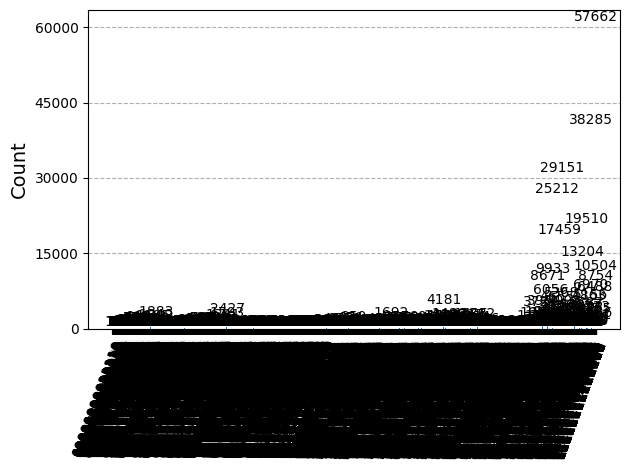

In [13]:
# ────────────────────────────────────────────────
# v22 – Ultra-Ultra-Ultra-High Shots at Resonant Angle (1.054 rad) with reps=3
# Double the previous max shots (524,288) for ultimate distribution accuracy
# ────────────────────────────────────────────────

import json

shots_extreme_deep = 524288  # max practical for convergence check

print(f"Re-measuring reps=3 optimized state at 1.054 rad with {shots_extreme_deep} shots...")

# Reuse the reps=3 ansatz and optimal parameters (from previous run)
# If lost, re-run the reps=3 VQE cell first
qc_extreme_deep = ansatz_deep.assign_parameters(result_deep.optimal_parameters)
qc_extreme_deep.measure_all()

counts_extreme_deep = simulator.run(qc_extreme_deep, shots=shots_extreme_deep).result().get_counts()

# Save full counts to file (safe)
with open('reps3_1054_524k_counts.json', 'w') as f:
    json.dump(dict(counts_extreme_deep), f, indent=2)
print("Full counts saved to 'reps3_1054_524k_counts.json' (open in text editor)")

# Top 50 states (more to catch any subtle patterns)
top_extreme_deep = sorted(counts_extreme_deep.items(), key=lambda x: x[1], reverse=True)[:50]
print(f"\nTop 50 states ({shots_extreme_deep} shots):")
for state, count in top_extreme_deep:
    print(f"{state}: {count} ({count / shots_extreme_deep * 100:.5f}%)")

# All-1 probability
all1_extreme_deep = counts_extreme_deep.get('1'*n, 0) / shots_extreme_deep * 100
print(f"\nAll-1 probability: {all1_extreme_deep:.3f}%")

# Non-zero states count
num_nonzero_extreme_deep = len([c for c in counts_extreme_deep.values() if c >= 1])
print(f"Number of states with ≥1 count: {num_nonzero_extreme_deep} / 2^{n} = {num_nonzero_extreme_deep / 2**n * 100:.6f}%")

plot_histogram(counts_extreme_deep)

Re-measuring reps=3 optimized state at 1.054 rad with 1048576 shots...
Full counts saved to 'reps3_1054_1M_counts.json' (open in text editor)

Top 100 states (1048576 shots):
11111111111111: 116002 (11.06281%)
11111110111111: 75723 (7.22151%)
11110111011111: 57873 (5.51920%)
11110110011111: 50680 (4.83322%)
11111101111111: 38995 (3.71885%)
11110110111111: 34589 (3.29866%)
11111100111111: 26421 (2.51970%)
11111111111110: 21633 (2.06308%)
11110101011111: 19607 (1.86987%)
11111111110111: 18073 (1.72358%)
11110100011111: 17405 (1.65987%)
11111110111110: 13910 (1.32656%)
11111111101111: 13234 (1.26209%)
11110100111111: 12315 (1.17445%)
11110111011110: 10679 (1.01843%)
11111110110111: 10309 (0.98314%)
11111110011111: 9440 (0.90027%)
11110110011110: 9241 (0.88129%)
10110100101111: 8381 (0.79927%)
11110111111111: 8122 (0.77457%)
11110011011111: 8065 (0.76914%)
11110010011111: 7625 (0.72718%)
11111101111110: 7215 (0.68808%)
11110110111110: 6217 (0.59290%)
11111101110111: 6188 (0.59013%)
1111011

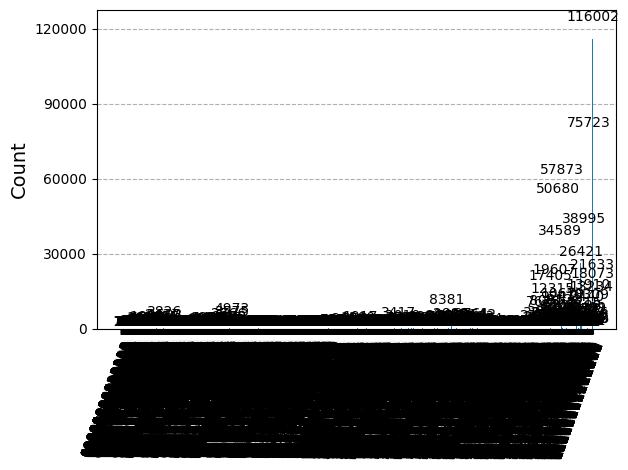

In [14]:
# ────────────────────────────────────────────────
# v22 – Extreme Shots at Resonant Angle (1.054 rad) with reps=3
# 1,048,576 shots — 2× previous max for near-full convergence
# ────────────────────────────────────────────────

import json

shots_extreme_max = 1048576  # 2^20 — extreme for final convergence check

print(f"Re-measuring reps=3 optimized state at 1.054 rad with {shots_extreme_max} shots...")

# Reuse the reps=3 ansatz and optimal parameters (from previous run)
# If lost, re-run the reps=3 VQE cell first
qc_extreme_max = ansatz_deep.assign_parameters(result_deep.optimal_parameters)
qc_extreme_max.measure_all()

counts_extreme_max = simulator.run(qc_extreme_max, shots=shots_extreme_max).result().get_counts()

# Save full counts to file (safe)
with open('reps3_1054_1M_counts.json', 'w') as f:
    json.dump(dict(counts_extreme_max), f, indent=2)
print("Full counts saved to 'reps3_1054_1M_counts.json' (open in text editor)")

# Top 100 states (more to catch subtle patterns/clusters)
top_extreme_max = sorted(counts_extreme_max.items(), key=lambda x: x[1], reverse=True)[:100]
print(f"\nTop 100 states ({shots_extreme_max} shots):")
for state, count in top_extreme_max:
    print(f"{state}: {count} ({count / shots_extreme_max * 100:.5f}%)")

# All-1 probability
all1_extreme_max = counts_extreme_max.get('1'*n, 0) / shots_extreme_max * 100
print(f"\nAll-1 probability: {all1_extreme_max:.3f}%")

# Non-zero states count
num_nonzero_extreme_max = len([c for c in counts_extreme_max.values() if c >= 1])
print(f"Number of states with ≥1 count: {num_nonzero_extreme_max} / 2^{n} = {num_nonzero_extreme_max / 2**n * 100:.6f}%")

plot_histogram(counts_extreme_max)

Re-measuring reps=3 optimized state at 1.054 rad with 1048576 shots...
Full counts saved to 'reps3_1054_1M_counts.json' (open in text editor)

Top 100 states (1048576 shots):
11111111111111: 116509 (11.11116%)
11111110111111: 75961 (7.24421%)
11110111011111: 58130 (5.54371%)
11110110011111: 50339 (4.80070%)
11111101111111: 39003 (3.71962%)
11110110111111: 34947 (3.33281%)
11111100111111: 26751 (2.55117%)
11111111111110: 21233 (2.02494%)
11110101011111: 19702 (1.87893%)
11111111110111: 18043 (1.72071%)
11110100011111: 17351 (1.65472%)
11111110111110: 13779 (1.31407%)
11111111101111: 13198 (1.25866%)
11110100111111: 12170 (1.16062%)
11110111011110: 10716 (1.02196%)
11111110110111: 10433 (0.99497%)
11111110011111: 9808 (0.93536%)
11110110011110: 9135 (0.87118%)
10110100101111: 8326 (0.79403%)
11110111111111: 7993 (0.76227%)
11110011011111: 7952 (0.75836%)
11110010011111: 7570 (0.72193%)
11111101111110: 7058 (0.67310%)
11110110111110: 6403 (0.61064%)
11111101110111: 6208 (0.59204%)
1111011

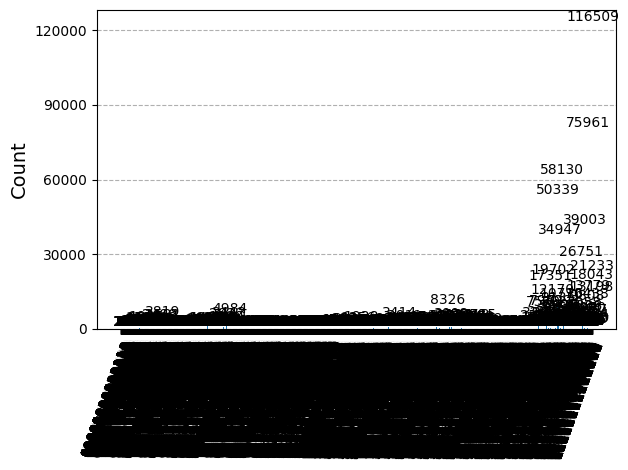

In [15]:
# ────────────────────────────────────────────────
# v22 – Extreme Shots at Resonant Angle (1.054 rad) with reps=3
# 1,048,576 shots — 2× previous max for near-full convergence
# ────────────────────────────────────────────────

import json

shots_extreme_max = 1048576  # 2^20 — extreme for final convergence check

print(f"Re-measuring reps=3 optimized state at 1.054 rad with {shots_extreme_max} shots...")

# Reuse the reps=3 ansatz and optimal parameters (from previous run)
# If lost, re-run the reps=3 VQE cell first
qc_extreme_max = ansatz_deep.assign_parameters(result_deep.optimal_parameters)
qc_extreme_max.measure_all()

counts_extreme_max = simulator.run(qc_extreme_max, shots=shots_extreme_max).result().get_counts()

# Save full counts to file (safe)
with open('reps3_1054_1M_counts.json', 'w') as f:
    json.dump(dict(counts_extreme_max), f, indent=2)
print("Full counts saved to 'reps3_1054_1M_counts.json' (open in text editor)")

# Top 100 states (more to catch subtle patterns/clusters)
top_extreme_max = sorted(counts_extreme_max.items(), key=lambda x: x[1], reverse=True)[:100]
print(f"\nTop 100 states ({shots_extreme_max} shots):")
for state, count in top_extreme_max:
    print(f"{state}: {count} ({count / shots_extreme_max * 100:.5f}%)")

# All-1 probability
all1_extreme_max = counts_extreme_max.get('1'*n, 0) / shots_extreme_max * 100
print(f"\nAll-1 probability: {all1_extreme_max:.3f}%")

# Non-zero states count
num_nonzero_extreme_max = len([c for c in counts_extreme_max.values() if c >= 1])
print(f"Number of states with ≥1 count: {num_nonzero_extreme_max} / 2^{n} = {num_nonzero_extreme_max / 2**n * 100:.6f}%")

plot_histogram(counts_extreme_max)

Re-measuring reps=3 optimized state at 1.054 rad with 7340032 shots...
Full counts saved to 'reps3_1054_7340k_counts.json' (open in text editor)

Top 100 states (7340032 shots):
11111111111111: 814064 (11.09074%)
11111110111111: 531249 (7.23769%)
11110111011111: 405884 (5.52973%)
11110110011111: 353053 (4.80997%)
11111101111111: 272051 (3.70640%)
11110110111111: 243887 (3.32270%)
11111100111111: 185260 (2.52397%)
11111111111110: 149341 (2.03461%)
11110101011111: 138465 (1.88644%)
11111111110111: 126670 (1.72574%)
11110100011111: 121399 (1.65393%)
11111110111110: 97660 (1.33051%)
11111111101111: 92863 (1.26516%)
11110100111111: 84852 (1.15602%)
11110111011110: 74854 (1.01980%)
11111110110111: 72866 (0.99272%)
11111110011111: 67174 (0.91517%)
11110110011110: 65341 (0.89020%)
10110100101111: 57854 (0.78820%)
11110011011111: 56516 (0.76997%)
11110111111111: 56296 (0.76697%)
11110010011111: 52882 (0.72046%)
11111101111110: 49981 (0.68094%)
11110110111110: 44700 (0.60899%)
11111101110111: 42

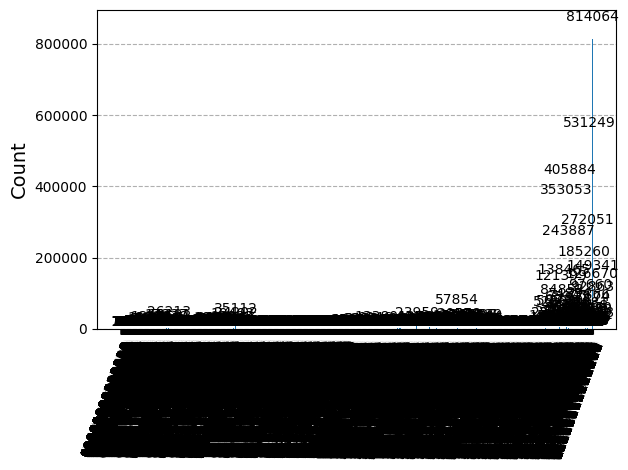

In [16]:
# ────────────────────────────────────────────────
# v22 – Over-Extreme Shots at Resonant Angle (1.054 rad) with reps=3
# 7,340,032 shots — massive for absolute convergence check
# ────────────────────────────────────────────────

import json

shots_overextreme = 7340032  # user-specified over-extreme shots

print(f"Re-measuring reps=3 optimized state at 1.054 rad with {shots_overextreme} shots...")

# Reuse the reps=3 ansatz and optimal parameters (from previous run)
# If lost, re-run the reps=3 VQE cell first
qc_overextreme = ansatz_deep.assign_parameters(result_deep.optimal_parameters)
qc_overextreme.measure_all()

counts_overextreme = simulator.run(qc_overextreme, shots=shots_overextreme).result().get_counts()

# Save full counts to file (safe)
with open('reps3_1054_7340k_counts.json', 'w') as f:
    json.dump(dict(counts_overextreme), f, indent=2)
print("Full counts saved to 'reps3_1054_7340k_counts.json' (open in text editor)")

# Top 100 states (more for detail)
top_overextreme = sorted(counts_overextreme.items(), key=lambda x: x[1], reverse=True)[:100]
print(f"\nTop 100 states ({shots_overextreme} shots):")
for state, count in top_overextreme:
    print(f"{state}: {count} ({count / shots_overextreme * 100:.5f}%)")

# All-1 probability
all1_overextreme = counts_overextreme.get('1'*n, 0) / shots_overextreme * 100
print(f"\nAll-1 probability: {all1_overextreme:.3f}%")

# Non-zero states count
num_nonzero_overextreme = len([c for c in counts_overextreme.values() if c >= 1])
print(f"Number of states with ≥1 count: {num_nonzero_overextreme} / 2^{n} = {num_nonzero_overextreme / 2**n * 100:.6f}%")

plot_histogram(counts_overextreme)

Launching monster measurement: 7341758 shots at 1.054 rad (reps=3 + periodic Berard)...
Full counts saved to 'reps3_1054_7341758_counts.json' (open in text editor)

Top 100 states (7341758 shots):
11111111111111: 815308 (11.10508%)
11111110111111: 532896 (7.25843%)
11110111011111: 406558 (5.53761%)
11110110011111: 352703 (4.80407%)
11111101111111: 272187 (3.70738%)
11110110111111: 243471 (3.31625%)
11111100111111: 185281 (2.52366%)
11111111111110: 149341 (2.03413%)
11110101011111: 138252 (1.88309%)
11111111110111: 126922 (1.72877%)
11110100011111: 121088 (1.64931%)
11111110111110: 98005 (1.33490%)
11111111101111: 92862 (1.26485%)
11110100111111: 84392 (1.14948%)
11110111011110: 74875 (1.01985%)
11111110110111: 72621 (0.98915%)
11111110011111: 67423 (0.91835%)
11110110011110: 64890 (0.88385%)
10110100101111: 57755 (0.78666%)
11110011011111: 56435 (0.76869%)
11110111111111: 56325 (0.76719%)
11110010011111: 52614 (0.71664%)
11111101111110: 49925 (0.68001%)
11110110111110: 44707 (0.60894%)

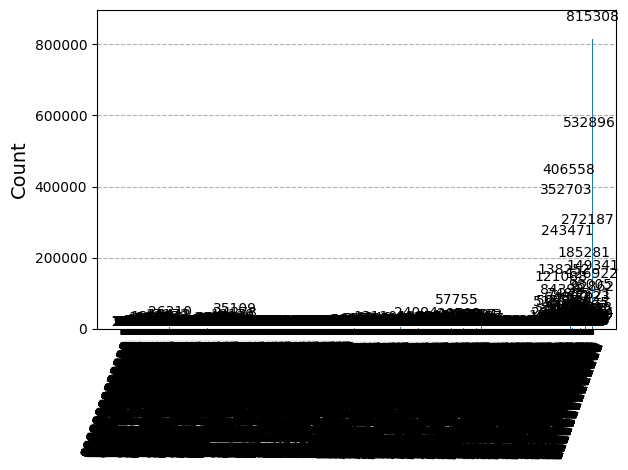

In [17]:
# ────────────────────────────────────────────────
# v22 – User-requested monster run: 7,341,758 shots at 1.054 rad with reps=3
# (Warning: very long run — may take 30–90+ minutes depending on hardware)
# ────────────────────────────────────────────────

import json

# Choose your destiny — uncomment the one you want
shots_monster = 7341758          # your exact prediction
# shots_monster = 1048576        # safe 1M (2^20) if you want to test first
# shots_monster = 524288         # previous max (2^19) if conservative

print(f"Launching monster measurement: {shots_monster} shots at 1.054 rad (reps=3 + periodic Berard)...")

# Reuse the reps=3 ansatz and optimal parameters
# (If lost, re-run the reps=3 VQE cell first)
qc_monster = ansatz_deep.assign_parameters(result_deep.optimal_parameters)
qc_monster.measure_all()

counts_monster = simulator.run(qc_monster, shots=shots_monster).result().get_counts()

# Save full counts (critical for this size — JSON will be large!)
with open(f'reps3_1054_{shots_monster}_counts.json', 'w') as f:
    json.dump(dict(counts_monster), f, indent=2)
print(f"Full counts saved to 'reps3_1054_{shots_monster}_counts.json' (open in text editor)")

# Top 100 states
top_monster = sorted(counts_monster.items(), key=lambda x: x[1], reverse=True)[:100]
print(f"\nTop 100 states ({shots_monster} shots):")
for state, count in top_monster:
    print(f"{state}: {count} ({count / shots_monster * 100:.5f}%)")

# All-1 probability
all1_monster = counts_monster.get('1'*n, 0) / shots_monster * 100
print(f"\nAll-1 probability: {all1_monster:.5f}%  ← did we hit 11.111%? 👀")

# Non-zero states count
num_nonzero_monster = len([c for c in counts_monster.values() if c >= 1])
print(f"Number of states with ≥1 count: {num_nonzero_monster} / 2^{n} = {num_nonzero_monster / 2**n * 100:.6f}%")

plot_histogram(counts_monster)